In [6]:
import tensorflow as tf

import matplotlib.pyplot as plt
import random
from pathlib import Path        #per gestire percorsi file

In [7]:
dir_prediction = Path("kagglehub/seg_pred")

#prende tutte le immagini .jpg presenti direttamente nella cartella
images_path = list(dir_prediction.glob("*.jpg"))

model = tf.keras.models.load_model('Modello/model_Tensorflow.keras')

In [8]:
IMG_SIZE = (150, 150)  #dim. immagine
seed = random.randint(0,1000000)             #seed

#trasformazione per le immagini destinati al training
prediction_data = tf.keras.utils.image_dataset_from_directory(dir_prediction,      #posizione cartella training
                                                            labels=None,           #dataset con immagini senza etichette
                                                            batch_size=64,
                                                            image_size=IMG_SIZE,   #impostazione grandezza 
                                                            seed = seed,
                                                            shuffle=True
                                                           )

classi=['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

Found 7301 files.


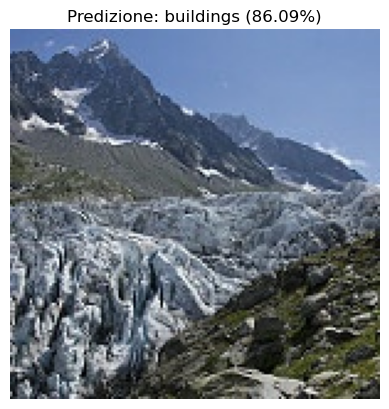

'exit' per uscire oppure invio per continuare:  


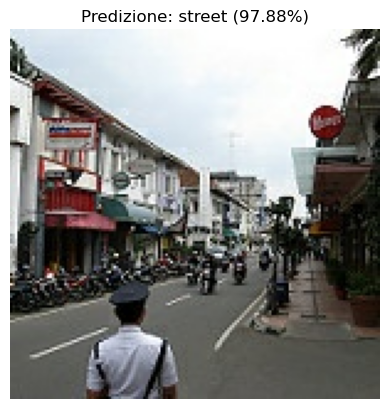

'exit' per uscire oppure invio per continuare:  


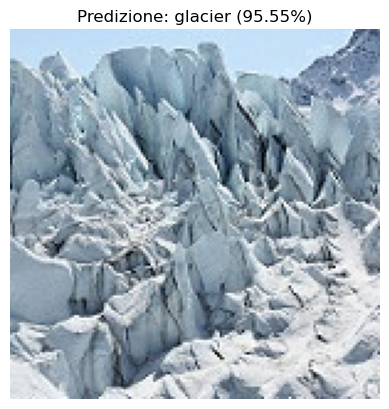

'exit' per uscire oppure invio per continuare:  


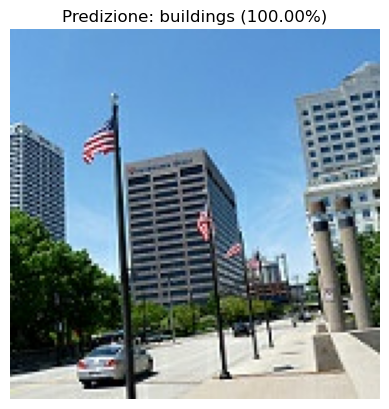

'exit' per uscire oppure invio per continuare:  


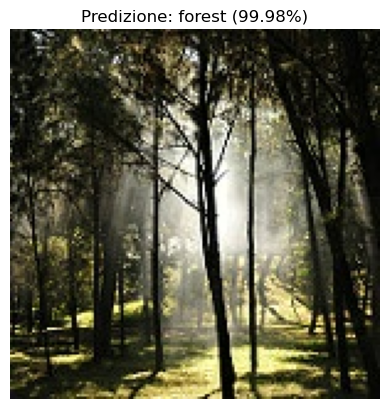

'exit' per uscire oppure invio per continuare:  


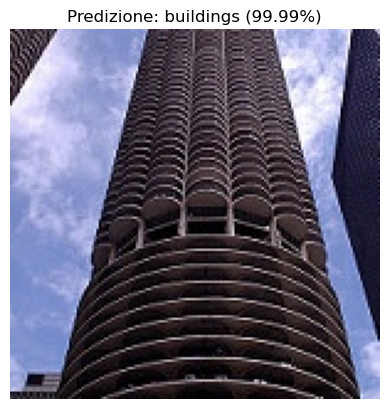

'exit' per uscire oppure invio per continuare:  


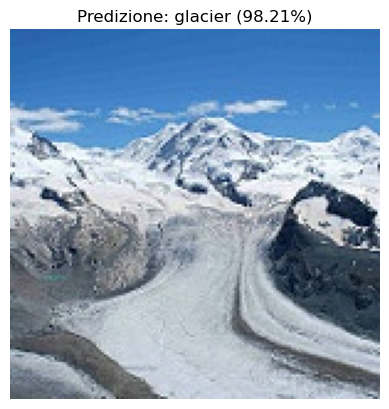

'exit' per uscire oppure invio per continuare:  


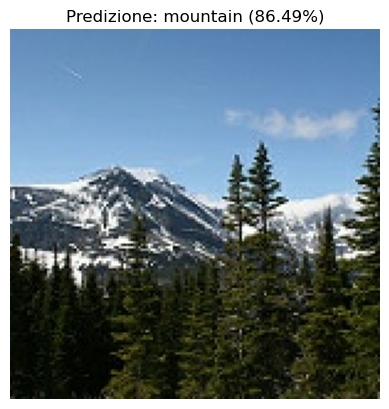

'exit' per uscire oppure invio per continuare:  


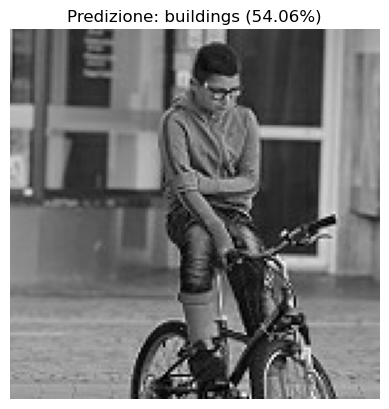

'exit' per uscire oppure invio per continuare:  


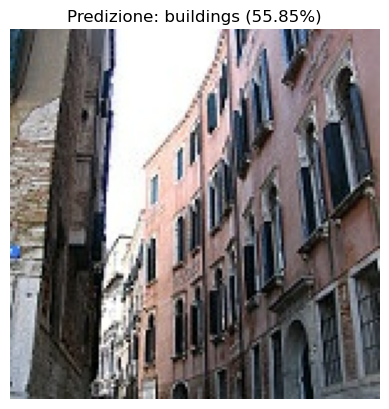

'exit' per uscire oppure invio per continuare:  


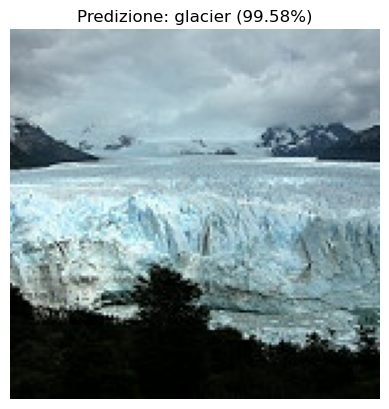

'exit' per uscire oppure invio per continuare:  


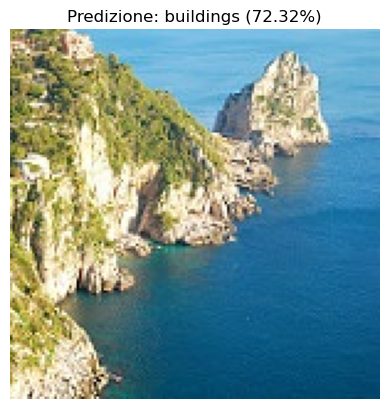

'exit' per uscire oppure invio per continuare:  


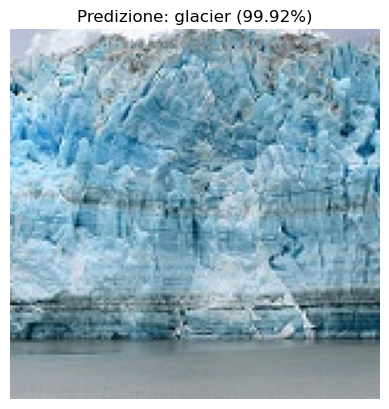

'exit' per uscire oppure invio per continuare:  


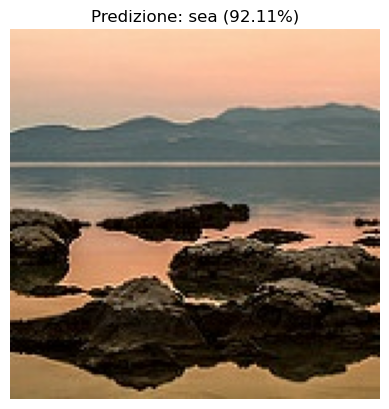

'exit' per uscire oppure invio per continuare:  


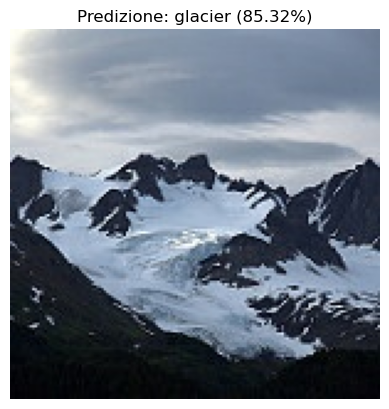

'exit' per uscire oppure invio per continuare:  


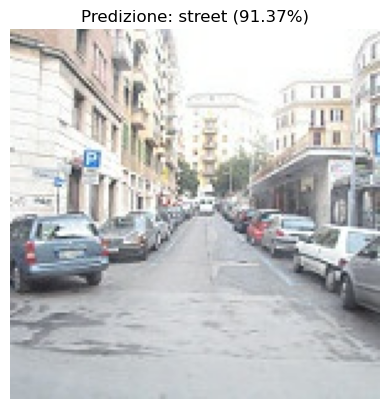

'exit' per uscire oppure invio per continuare:  


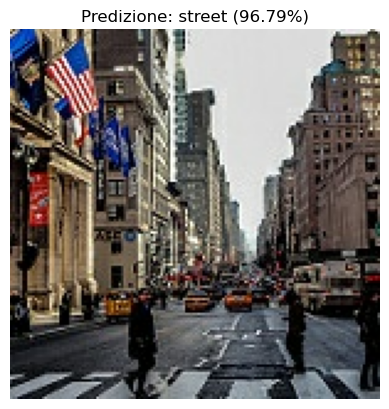

'exit' per uscire oppure invio per continuare:  


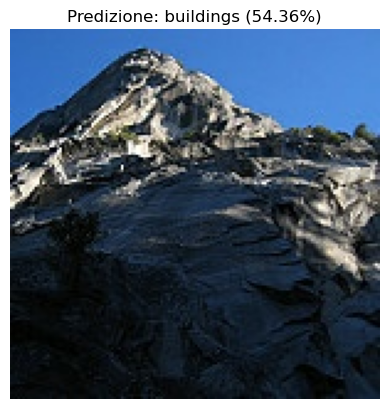

'exit' per uscire oppure invio per continuare:  


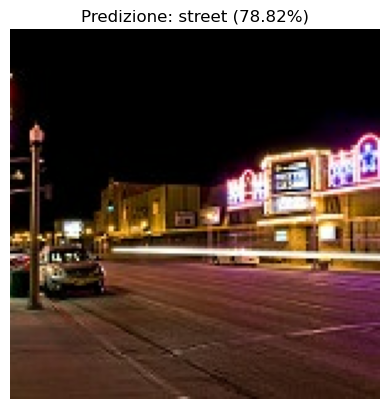

'exit' per uscire oppure invio per continuare:  


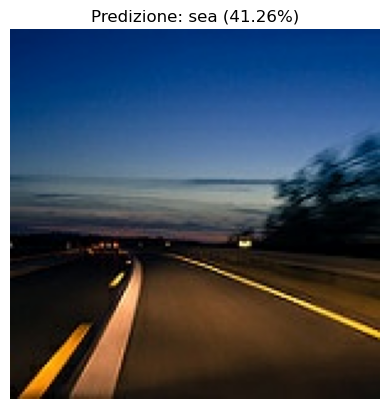

'exit' per uscire oppure invio per continuare:  


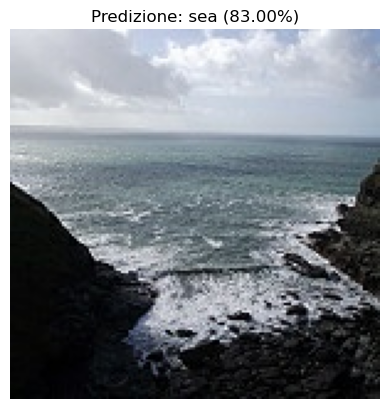

'exit' per uscire oppure invio per continuare:  


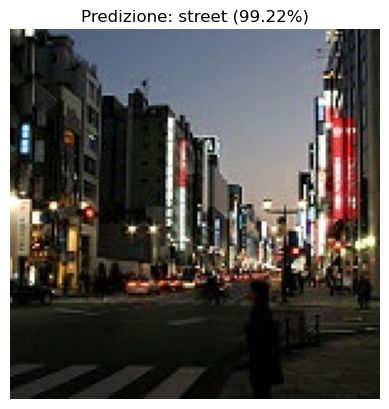

'exit' per uscire oppure invio per continuare:  


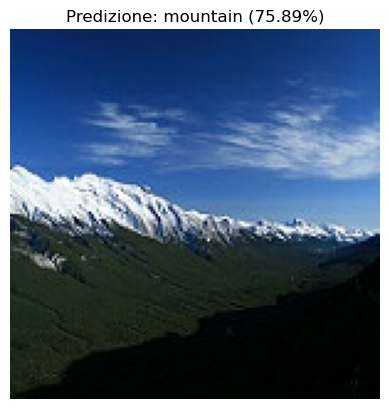

'exit' per uscire oppure invio per continuare:  


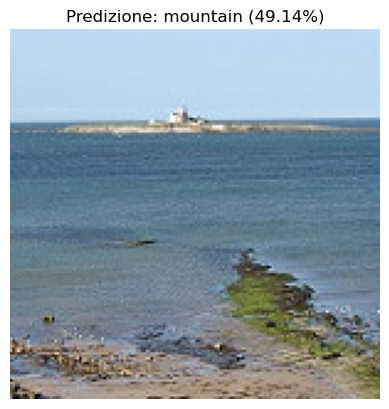

'exit' per uscire oppure invio per continuare:  


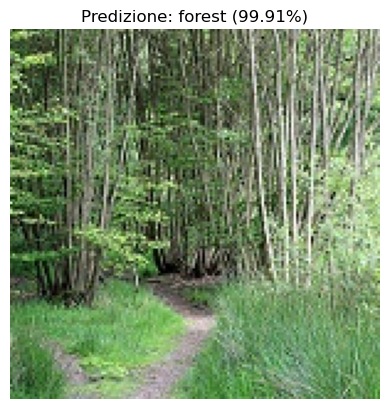

'exit' per uscire oppure invio per continuare:  


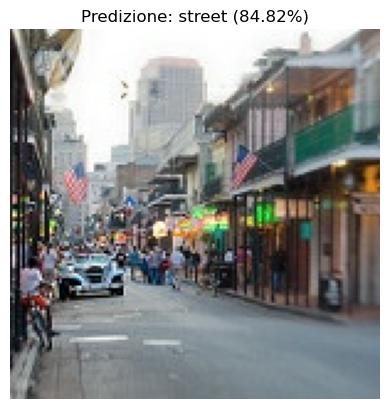

In [ ]:
check = ""

while check != "exit":
    random_dataset = prediction_data.unbatch().shuffle(1000).batch(1) #prende un immagine casuale dal tutto il dataset
    
    random_image = next(iter(random_dataset)) #il puntatore estrae l'immagine dal random_datset

    predictions = model.predict(random_image, verbose=0)  #restituisce il vettore output (verbose=0 impedisce la stampa della barra di caricamento)

    classe_idx = int(tf.argmax(predictions[0]))     #restituisce la pos del valore più alto
    classe_predetta = classi[classe_idx]            #restituisce la classe che appartiene il risultato

    confidence = float(tf.reduce_max(predictions[0])) * 100 #il valore del risultato in percentuale


    #stampa dell'immagine
    plt.figure()
    plt.axis("off")
    plt.imshow(tf.cast(random_image[0], tf.uint8))
    plt.title(f"Predizione: {classe_predetta} ({confidence:.2f}%)")
    plt.show()

    check = input("'exit' per uscire oppure invio per continuare: ")